# Data Preprocessing & Feature Engineering Strategy
**Dataset:** IBM Telco Customer Churn (public, 7,043 customers x 21 columns)  
**Goal:** Build a leakage-free preprocessing pipeline and show, with evidence, what each step changes.  
**Author:** Roshanpreet Singh

## 1. Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif, RFE
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, f1_score
from scipy import stats
sns.set_theme(style='whitegrid'); RS=42
import os; os.makedirs('figures', exist_ok=True)
df = pd.read_csv('data/Telco-Customer-Churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Data understanding

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
print(df['Churn'].value_counts())
print((df['Churn'].value_counts(normalize=True)*100).round(2))
print('customerID unique:', df['customerID'].is_unique)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64
customerID unique: True


## 3. Data quality analysis

In [4]:
print('Real NaNs per column:', int(df.isna().sum().sum()))
print('Duplicate rows       :', int(df.duplicated().sum()))
# Hidden missing values: TotalCharges is text, so blanks are not detected by isna()
blank = df['TotalCharges'].str.strip() == ''
print('Blank TotalCharges   :', int(blank.sum()))
df.loc[blank, ['customerID','tenure','MonthlyCharges','TotalCharges','Churn']]

Real NaNs per column: 0
Duplicate rows       : 0
Blank TotalCharges   : 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [5]:
# Are blanks related to tenure = 0 (brand-new customers)?
print('tenure==0 rows:', int((df.tenure==0).sum()), '| blanks that have tenure==0:', int((blank & (df.tenure==0)).sum()))

tenure==0 rows: 11 | blanks that have tenure==0: 11


## 4. Descriptive statistics & visualisation

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
num_cols = ['tenure','MonthlyCharges','TotalCharges']
print(df[num_cols].describe().round(2))
print('\nSkewness:'); print(df[num_cols].skew().round(3))

        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7032.00
mean     32.37           64.76       2283.30
std      24.56           30.09       2266.77
min       0.00           18.25         18.80
25%       9.00           35.50        401.45
50%      29.00           70.35       1397.48
75%      55.00           89.85       3794.74
max      72.00          118.75       8684.80

Skewness:
tenure            0.240
MonthlyCharges   -0.221
TotalCharges      0.962
dtype: float64


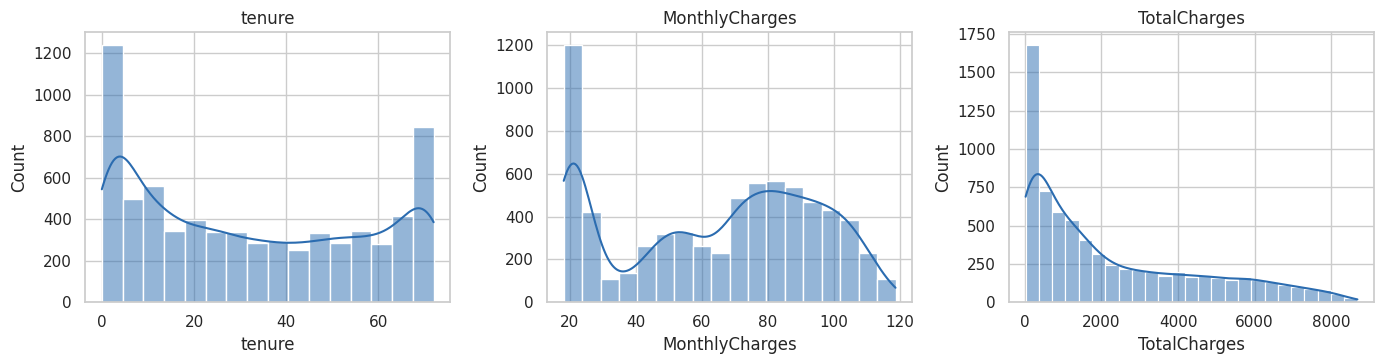

In [7]:
fig, ax = plt.subplots(1,3, figsize=(14,3.8))
for a,c in zip(ax,num_cols):
    sns.histplot(df[c].dropna(), kde=True, ax=a, color='#2b6cb0'); a.set_title(c)
plt.tight_layout(); plt.savefig('figures/fig1_distributions.png', dpi=130); plt.show()

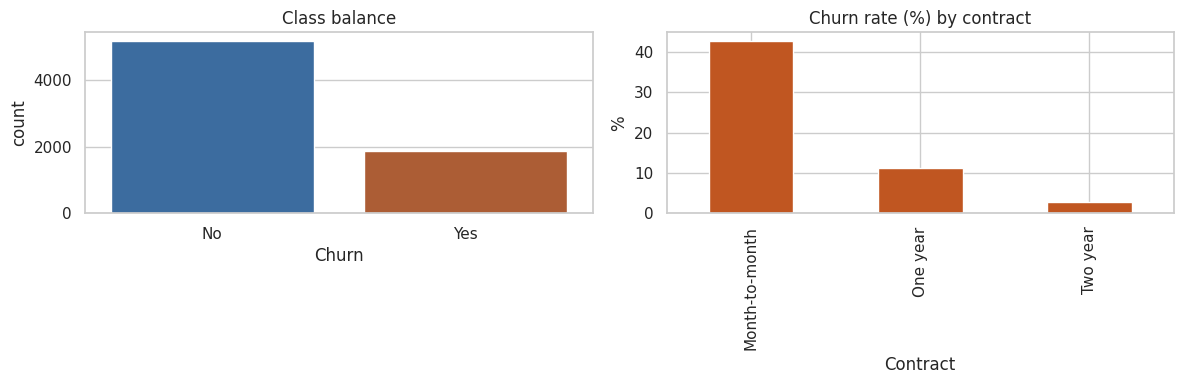

Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: c, dtype: float64


In [8]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.countplot(x='Churn', data=df, ax=ax[0], palette=['#2b6cb0','#c05621']); ax[0].set_title('Class balance')
order=['Month-to-month','One year','Two year']
rate = df.assign(c=(df.Churn=='Yes')).groupby('Contract')['c'].mean().reindex(order)*100
rate.plot.bar(ax=ax[1], color='#c05621'); ax[1].set_title('Churn rate (%) by contract'); ax[1].set_ylabel('%')
plt.tight_layout(); plt.savefig('figures/fig2_churn.png', dpi=130); plt.show()
print(rate.round(1))

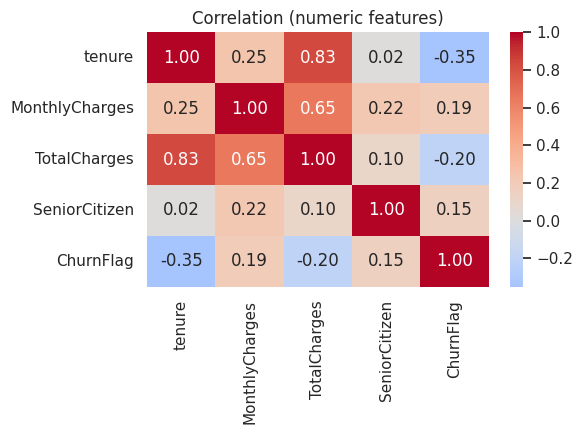

In [9]:
d = df.copy(); d['ChurnFlag']=(d.Churn=='Yes').astype(int)
corr = d[num_cols+['SeniorCitizen','ChurnFlag']].corr()
plt.figure(figsize=(6,4.5)); sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation (numeric features)'); plt.tight_layout(); plt.savefig('figures/fig3_corr.png', dpi=130); plt.show()

## 5. Data cleaning

### 5.1 Missing values: compare strategies for `TotalCharges`

In [10]:
print('NaNs after numeric conversion:', int(df.TotalCharges.isna().sum()))
print(df.loc[df.TotalCharges.isna(), 'tenure'].unique(), '<- all have tenure 0')
opts = {}
opts['mean imputation']   = df['TotalCharges'].fillna(df['TotalCharges'].mean())
opts['median imputation'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
opts['domain rule (0 for tenure 0)'] = df['TotalCharges'].fillna(0)
for k,v in opts.items():
    print(f'{k:30s} fill value on affected rows = {v[df.TotalCharges.isna()].iloc[0]:.2f}')

NaNs after numeric conversion: 11
[0] <- all have tenure 0
mean imputation                fill value on affected rows = 2283.30
median imputation              fill value on affected rows = 1397.47
domain rule (0 for tenure 0)   fill value on affected rows = 0.00


In [11]:
# Decision: customers with tenure 0 have not been billed yet -> TotalCharges = 0 is the logically correct value
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print('Remaining NaNs:', int(df.isna().sum().sum()))

Remaining NaNs: 0


### 5.2 Duplicates

In [12]:
print('Full-row duplicates      :', int(df.duplicated().sum()))
print('Duplicate customerIDs     :', int(df['customerID'].duplicated().sum()))
df = df.drop(columns='customerID')   # identifier carries no signal

Full-row duplicates      : 0
Duplicate customerIDs     : 0


### 5.3 Outliers (IQR vs z-score)

In [13]:
rows=[]
for c in num_cols:
    q1,q3=df[c].quantile([.25,.75]); iqr=q3-q1
    lo,hi=q1-1.5*iqr,q3+1.5*iqr
    iqr_n=int(((df[c]<lo)|(df[c]>hi)).sum())
    z_n=int((np.abs(stats.zscore(df[c]))>3).sum())
    rows.append([c, round(lo,1), round(hi,1), iqr_n, z_n])
out = pd.DataFrame(rows, columns=['feature','IQR_low','IQR_high','IQR_outliers','z>3_outliers']); out

,feature,IQR_low,IQR_high,IQR_outliers,z>3_outliers
0,tenure,-60.0,124.0,0,0
1,MonthlyCharges,-46.0,171.4,0,0
2,TotalCharges,-4683.5,8868.7,0,0


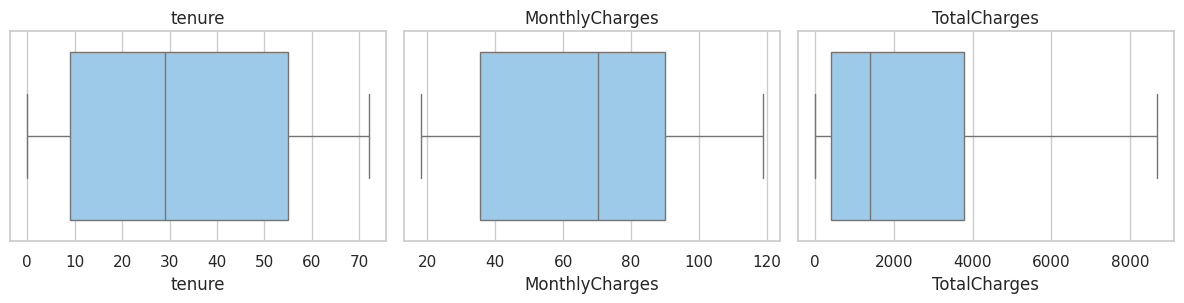

In [14]:
fig, ax = plt.subplots(1,3, figsize=(12,3.2))
for a,c in zip(ax,num_cols): sns.boxplot(x=df[c], ax=a, color='#90cdf4'); a.set_title(c)
plt.tight_layout(); plt.savefig('figures/fig4_boxplots.png', dpi=130); plt.show()

**Finding:** no numeric feature has outliers by the IQR rule; the values are legitimate (long-tenure and high-bill customers), so we **keep** them and handle skew with a transform instead of deleting rows.

## 6. Feature engineering

Skew TotalCharges before log1p: 0.963
Skew TotalCharges after  log1p: -0.824


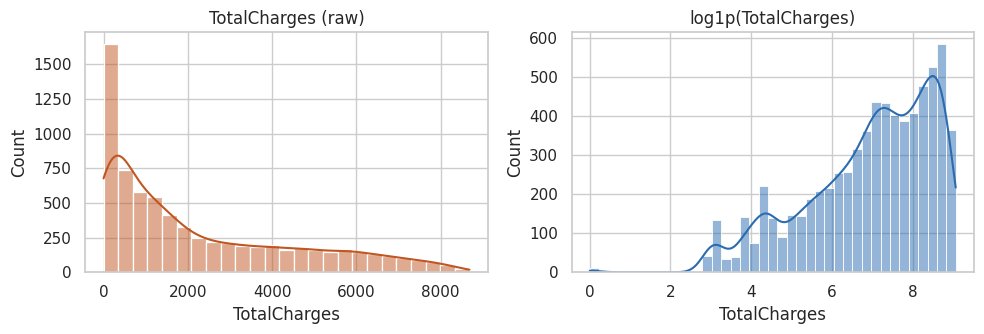

In [15]:
print('Skew TotalCharges before log1p:', round(df.TotalCharges.skew(),3))
print('Skew TotalCharges after  log1p:', round(np.log1p(df.TotalCharges).skew(),3))
fig, ax = plt.subplots(1,2, figsize=(10,3.5))
sns.histplot(df.TotalCharges, kde=True, ax=ax[0], color='#c05621'); ax[0].set_title('TotalCharges (raw)')
sns.histplot(np.log1p(df.TotalCharges), kde=True, ax=ax[1], color='#2b6cb0'); ax[1].set_title('log1p(TotalCharges)')
plt.tight_layout(); plt.savefig('figures/fig5_log.png', dpi=130); plt.show()

In [16]:
svc = ['PhoneService','MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
fe = df.copy()
fe['y'] = (fe.Churn=='Yes').astype(int)
fe['tenure_group']   = pd.cut(fe.tenure, [-1,12,24,48,72], labels=['0-12','13-24','25-48','49-72'])
fe['num_services']   = sum((fe[c]=='Yes').astype(int) for c in svc) + (fe.InternetService!='No').astype(int)
fe['avg_monthly_paid'] = np.where(fe.tenure>0, fe.TotalCharges/fe.tenure.replace(0,1), fe.MonthlyCharges)
fe['charge_gap']     = fe.MonthlyCharges - fe['avg_monthly_paid']
fe['has_streaming']  = ((fe.StreamingTV=='Yes')|(fe.StreamingMovies=='Yes')).astype(int)
fe['has_protection'] = ((fe.OnlineSecurity=='Yes')|(fe.TechSupport=='Yes')|(fe.DeviceProtection=='Yes')).astype(int)
fe['auto_pay']       = fe.PaymentMethod.str.contains('automatic').astype(int)
fe['log_total']      = np.log1p(fe.TotalCharges)
new = ['tenure_group','num_services','avg_monthly_paid','charge_gap','has_streaming','has_protection','auto_pay','log_total']
print(fe[new].head())
print()
print(fe.groupby('tenure_group', observed=True)['y'].mean().mul(100).round(1).rename('churn % by tenure group'))
print(fe.groupby('has_protection')['y'].mean().mul(100).round(1).rename('churn % by has_protection'))
print(fe.groupby('auto_pay')['y'].mean().mul(100).round(1).rename('churn % by auto_pay'))

  tenure_group  num_services  avg_monthly_paid  charge_gap  has_streaming  \
0         0-12             2         29.850000    0.000000              0   
1        25-48             4         55.573529    1.376471              0   
2         0-12             4         54.075000   -0.225000              0   
3        25-48             4         40.905556    1.394444              0   
4         0-12             2         75.825000   -5.125000              0   

   has_protection  auto_pay  log_total  
0               0         0   3.429137  
1               1         0   7.544597  
2               1         0   4.692723  
3               1         1   7.518471  
4               0         0   5.028148  

tenure_group
0-12     47.4
13-24    28.7
25-48    20.4
49-72     9.5
Name: churn % by tenure group, dtype: float64
has_protection
0    31.5
1    22.3
Name: churn % by has_protection, dtype: float64
auto_pay
0    34.7
1    16.0
Name: churn % by auto_pay, dtype: float64


## 7. Encoding & scaling

In [17]:
# Encoding plan
binary = ['gender','Partner','Dependents','PhoneService','PaperlessBilling']
ordinal = ['Contract']                       # natural order
nominal = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection',
           'TechSupport','StreamingTV','StreamingMovies','PaymentMethod','tenure_group']
numeric = ['tenure','MonthlyCharges','TotalCharges','log_total','num_services','avg_monthly_paid','charge_gap']
passthrough = ['SeniorCitizen','has_streaming','has_protection','auto_pay']
X = fe.drop(columns=['Churn','y']); y = fe['y']
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RS)
print('train', Xtr.shape, 'test', Xte.shape, '| churn rate train/test:', round(ytr.mean(),3), round(yte.mean(),3))

train (5634, 27) test (1409, 27) | churn rate train/test: 0.265 0.265


In [18]:
# StandardScaler vs MinMaxScaler on a skewed feature (fit on TRAIN only)
ss=StandardScaler().fit(Xtr[['TotalCharges']]); mm=MinMaxScaler().fit(Xtr[['TotalCharges']])
cmp = pd.DataFrame({'raw':Xtr.TotalCharges,'standard':ss.transform(Xtr[['TotalCharges']]).ravel(),'minmax':mm.transform(Xtr[['TotalCharges']]).ravel()})
print(cmp.describe().loc[['mean','std','min','max']].round(3))

           raw  standard  minmax
mean  2299.335     0.000   0.265
std   2279.204     1.000   0.262
min      0.000    -1.009   0.000
max   8684.800     2.802   1.000


In [19]:
pre = ColumnTransformer([
    ('bin', OrdinalEncoder(), binary),
    ('ord', OrdinalEncoder(categories=[['Month-to-month','One year','Two year']]), ordinal),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal),
    ('num', StandardScaler(), numeric),
    ('pas', 'passthrough', passthrough)])
Xtr_t = pre.fit_transform(Xtr); Xte_t = pre.transform(Xte)
names = list(pre.get_feature_names_out())
print('Features before:', Xtr.shape[1], '-> after encoding/scaling:', Xtr_t.shape[1])
print('NaNs in output:', int(np.isnan(Xtr_t).sum()))

Features before: 27 -> after encoding/scaling: 49
NaNs in output: 0


## 8. Feature selection

In [20]:
Xtr_df = pd.DataFrame(Xtr_t, columns=names)
# (a) correlation filter: highly redundant pairs
cm = Xtr_df.corr().abs(); up = cm.where(np.triu(np.ones(cm.shape),1).astype(bool))
pairs = up.stack().sort_values(ascending=False); print('Highly correlated pairs (>0.9):'); print(pairs[pairs>0.9].round(3).head(12))

Highly correlated pairs (>0.9):
ohe__InternetService_No                  ohe__OnlineSecurity_No internet service      1.0
                                         ohe__TechSupport_No internet service         1.0
ohe__OnlineSecurity_No internet service  ohe__DeviceProtection_No internet service    1.0
ohe__InternetService_No                  ohe__StreamingTV_No internet service         1.0
                                         ohe__StreamingMovies_No internet service     1.0
                                         ohe__OnlineBackup_No internet service        1.0
                                         ohe__DeviceProtection_No internet service    1.0
ohe__OnlineSecurity_No internet service  ohe__TechSupport_No internet service         1.0
                                         ohe__OnlineBackup_No internet service        1.0
ohe__TechSupport_No internet service     ohe__StreamingTV_No internet service         1.0
ohe__OnlineBackup_No internet service    ohe__TechSupport_No interne

In [21]:
# (b) mutual information
mi = pd.Series(mutual_info_classif(Xtr_df, ytr, random_state=RS), index=names).sort_values(ascending=False)
print(mi.head(10).round(4))

ord__Contract                                0.0944
num__tenure                                  0.0674
ohe__OnlineSecurity_No                       0.0637
ohe__TechSupport_No                          0.0619
num__MonthlyCharges                          0.0511
ohe__InternetService_Fiber optic             0.0496
ohe__DeviceProtection_No internet service    0.0466
ohe__tenure_group_0-12                       0.0457
num__charge_gap                              0.0429
ohe__PaymentMethod_Electronic check          0.0413
dtype: float64


RFE top-15: ['bin__PaperlessBilling', 'ord__Contract', 'ohe__MultipleLines_No', 'ohe__InternetService_DSL', 'ohe__InternetService_Fiber optic', 'ohe__InternetService_No', 'ohe__DeviceProtection_No internet service', 'ohe__TechSupport_No internet service', 'ohe__StreamingTV_No', 'ohe__StreamingTV_No internet service', 'ohe__StreamingMovies_No internet service', 'ohe__StreamingMovies_Yes', 'ohe__PaymentMethod_Mailed check', 'num__log_total', 'pas__auto_pay']

num__log_total                      0.0953
num__TotalCharges                   0.0928
num__avg_monthly_paid               0.0887
num__MonthlyCharges                 0.0881
num__tenure                         0.0853
num__charge_gap                     0.0714
ord__Contract                       0.0523
ohe__OnlineSecurity_No              0.0303
ohe__InternetService_Fiber optic    0.0252
ohe__TechSupport_No                 0.0245
dtype: float64


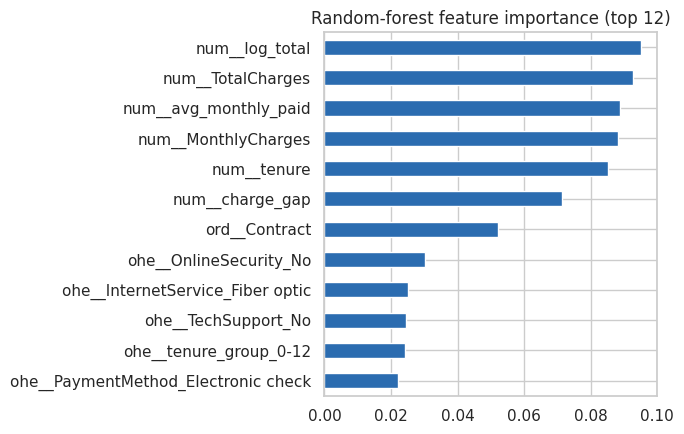

In [22]:
# (c) RFE with logistic regression and (d) random-forest importance
rfe = RFE(LogisticRegression(max_iter=2000), n_features_to_select=15).fit(Xtr_df, ytr)
rfe_feats = [n for n,s in zip(names, rfe.support_) if s]
rf = RandomForestClassifier(n_estimators=300, random_state=RS, n_jobs=-1).fit(Xtr_df, ytr)
imp = pd.Series(rf.feature_importances_, index=names).sort_values(ascending=False)
print('RFE top-15:', rfe_feats); print(); print(imp.head(10).round(4))
fig,ax=plt.subplots(figsize=(7,4.5)); imp.head(12)[::-1].plot.barh(ax=ax,color='#2b6cb0'); ax.set_title('Random-forest feature importance (top 12)')
plt.tight_layout(); plt.savefig('figures/fig6_importance.png', dpi=130); plt.show()

## 9. Dimensionality reduction (PCA)

90% variance needs 15 of 49 components
95% variance needs 19 of 49 components


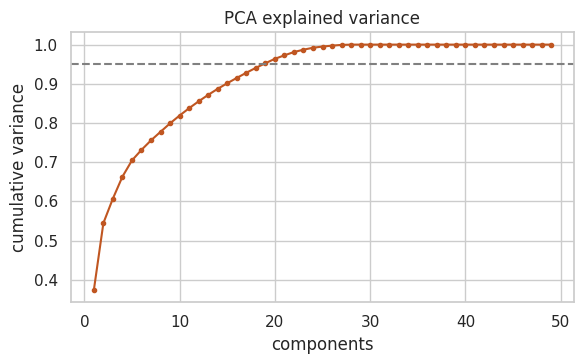

In [23]:
p = PCA().fit(Xtr_df); cum = np.cumsum(p.explained_variance_ratio_)
for t in (0.90,0.95): print(f'{int(t*100)}% variance needs {int(np.argmax(cum>=t))+1} of {len(cum)} components')
plt.figure(figsize=(6,3.8)); plt.plot(range(1,len(cum)+1), cum, marker='o', ms=3, color='#c05621')
plt.axhline(.95, ls='--', c='grey'); plt.xlabel('components'); plt.ylabel('cumulative variance'); plt.title('PCA explained variance')
plt.tight_layout(); plt.savefig('figures/fig7_pca.png', dpi=130); plt.show()

## 10. Does preprocessing actually help? (validation)

In [24]:
skf = StratifiedKFold(5, shuffle=True, random_state=RS)
# Baseline: minimal prep (drop blanks rows, one-hot everything, no scaling, no engineered features)
base_cols = [c for c in X.columns if c not in new]
base_num = ['tenure','MonthlyCharges','TotalCharges','SeniorCitizen']
base_cat = [c for c in base_cols if c not in base_num]
base_pre = ColumnTransformer([('c', OneHotEncoder(handle_unknown='ignore'), base_cat)], remainder='passthrough')
res = {}
for name, pipe, cols in [
    ('Baseline (no scaling, no new features)', Pipeline([('p',base_pre),('m',LogisticRegression(max_iter=3000))]), base_cols),
    ('Full pipeline (this report)',            Pipeline([('p',pre),('m',LogisticRegression(max_iter=3000))]),       list(X.columns))]:
    auc = cross_val_score(pipe, Xtr[cols], ytr, cv=skf, scoring='roc_auc')
    f1  = cross_val_score(pipe, Xtr[cols], ytr, cv=skf, scoring='f1')
    pipe.fit(Xtr[cols], ytr); p = pipe.predict_proba(Xte[cols])[:,1]
    res[name] = [auc.mean(), f1.mean(), roc_auc_score(yte,p), f1_score(yte,(p>.5).astype(int))]
r = pd.DataFrame(res, index=['CV ROC-AUC','CV F1','Test ROC-AUC','Test F1']).T.round(4); r

,CV ROC-AUC,CV F1,Test ROC-AUC,Test F1
"Baseline (no scaling, no new features)",0.8463,0.5932,0.8423,0.6081
Full pipeline (this report),0.8488,0.5996,0.8460,0.5956


In [25]:
# Using only the top-15 RFE features
sel = [i for i,n in enumerate(names) if n in rfe_feats]
m = LogisticRegression(max_iter=3000).fit(Xtr_t[:,sel], ytr)
p = m.predict_proba(Xte_t[:,sel])[:,1]
print('Top-15 RFE features -> Test ROC-AUC:', round(roc_auc_score(yte,p),4), '| Test F1:', round(f1_score(yte,(p>.5).astype(int)),4))
print('All', len(names), 'features        -> Test ROC-AUC:', r.loc['Full pipeline (this report)','Test ROC-AUC'])

Top-15 RFE features -> Test ROC-AUC: 0.8458 | Test F1: 0.5931
All 49 features        -> Test ROC-AUC: 0.846


## 11. Takeaways
- Hidden missing values (blank strings) are invisible to `isna()`; always check dtypes.
- Domain logic (tenure 0 -> TotalCharges 0) beat statistical imputation.
- Fit encoders/scalers on the training split only to avoid leakage.
- Engineered features (tenure groups, service counts, protection/auto-pay flags) capture patterns raw columns hide.